$$\require{mchem}$$
# **Conformational sampling using Molecular Dynamics** 

<span style="color:darkred;"> **Summary** :   Knowing how to compute the potential energy and forces of a model system, we resort to the MD approach to follow the dynamics of biomolecules because MD is conceptually simple, physically appealing and a versatile simulation technique.  In this session, we introduce the critical parameters that define and control conventional and enhanced MD simulation jobs. In addition, we analyze the GAMD simulation launched at the previous session to select a starting point for the subsequent  conventional MD. 

## **Fundamentals of  Molecular Dynamics**

### **Molecular Dynamics: An *experimental* technique**  
Molecular Dynamics (MD) simulations reproduce the thermal wandering of molecules through rugged energy landscapes by solving the Newton's equation of motion for a system of $N$ interacting particles. The adoption of *classical* equations of motion, which is in consonance with the  Born-Oppenheimer approximation,  yields excellent results for molecular systems and materials at typical pressure and temperature conditions.   

Interestingly, MD simulations can be considered as *in silico* experiments that resemble real experiments in many respects. Some similarities between the two approaches are enumerated in the following Table:  
| Stage  | Real experiment | Computational experiment  |
| --- | ---  | ---  | 
|  **1** |  Prepare sample |  Molecular edition of model system |
|  **2** |  Connect sample to a measuring instrument  |  Connect model to an MD *engine*   |
|  **3** |  Measure the property of interest during a certain time interval  |  Sample molecular properties over a certain simulation time   |

Moreover, the most common mistakes in MD simulations are similar to mistakes that can be made in real experiments.  Some examples are:    

| Stage  | Mistakes in real experiment | Mistakes in computational experiment  |
| --- | ---  | ---  | 
|  **1** |  Sample not prepared correctly |  Solvent box too small. Poor force field selection |
|  **2** |  Select inadequate instrument or settings  |  Use obsolete  hardware/software. Select wrong MD settings   |
|  **3** |  System undergoes an irreversible change. Measurement(s) are too short |  Simulation time is too short. MD post-processing and analysis poorly performed      |

The close interplay between computer-based and real experiments is especially fruitful in the structural determination of biomolecules by **NMR spectroscopy**. Thus, the experimental structures  are generated by converting NMR signals into geometrical constraints, which are then used to search for compatible 3D conformations using MD simulation techniques.

[x]:![](PNG/animation.gif)
<img src="./PNG/animation.gif" width="480" height="240" style="display: block; margin: 0 auto">

**Fig 1** 3D models of the 7V3T NMR structure of G-quadruplet aptamer.  Molecular modeling plays a key role in determining the most likely NMR structures.  

### **MD is a multi-purpose technique**

Some **advantages of the MD approach** in combination with MM potentials are:

* MDs can unveil structural and dynamic properties at the molecular level that remain largely inaccessible to experimental techniques.
* In principle, any physical quantity that is expressed as a function of position and momenta (velocity) can be measured by MDs. 
* MDs can simulate equilibrium and non-equilibrium systems. Special MD techniques can perform  preferential or enhanced sampling for selected degrees of freedom.   
* Post-processing of MD data can estimate probability density functions (PDFs) that, in turn, allow the calculation of thermodynamic quantities ($\Delta G$, $S_{conform}$, ...). 

Thanks to these and other characteristics, a wide range of computational experiments can be designed and performed by means of MD simulations. There are, however, two **major sources of error** in any well-executed MD simulation:

* Errors inherent to the MM or QM potentials utilized to compute the required forces   
* Errors due to the *limited* amount of sampling achieved by MD simulations 

Assessing the magnitude and/or actual impact of these errors in a given MD simulation is rather difficult, especially in the absence of relevant  experimental information. In practical terms, the reliability of MD simulations can be supported by former validation studies,  measurements of statistical  uncertainty,  convergence analysis, multi-MD protocols, etc. Therefore, **caution is needed to interpret the results of  MD experiments**. 

Concerning the applicability of MD simulations, this is limited by three factors: 
1. The underlying potential energy model (e.g. AMBER potentials cannot describe chemical reactivity).  
2. The size and complexity of the model systems and processes to be studied.
3. The available hardware &  computer time resources.

As MD simulations can be very expensive and require complicated workflows, their current applicability limits need to be considered a priori.

* **Q1**  This nice [web application](https://physics.weber.edu/schroeder/md/) performs interactive 2D MD simulations of different systems composed of Lennard-Jones particles. Run interactive MDs for a system composed of diatomic molecules and take note of the effects upon changes of settings :
    1. Increase (*faster*) or decrease (*slower*) kinetic energy. 
    2. Monitor the time evolution of temperature and energy (expressed in reduced units).
    3. What is the meaning of the  **time step** ($\Delta t$) setting? Which  value(s) can be assigned to $\Delta t$  ? Increment $\Delta t$ .  What happens?

### **The core of MD: numerical integration of equations of motion**     

The best introduction to MD is to consider the structure of a simple program to run MD:    

1. Read the settings of the run (temperature $T$, number of particles $N$, box size, time step $\Delta t$, number of steps).
2. Initialization of positions ${\bf{r}}(t)$, velocities ${\bf{v}}(t)$ and time counter $t=0$.
---
3. Compute the forces on all particles ${\bf{F}}(t)$.
4. Update velocities and positions at $t+\Delta t$ integrating Newton's equations of motion with **numerical algorithms**.
    Steps 3 and 4 are repeated for the requested number of steps
---
5. After completion of the central *loop*, compute and print  averages of measured quantities, and stop.

[x]:![](PNG/integrate.png)
<img src="./PNG/integrate.png" width="640" height="360" style="display: block; margin: 0 auto">

**Fig 2** The core of an MD simulation repeats the steps of force calculation and coordinate/velocity update (formulas shown here are too simplistic).

In [ ]:
# Pseudo code representation of a MD program 
def main: 
    set_positions_parameters # function to initialize/read positions and
                             # MD settings (temp, tmax, delt, ...)
    initv(temp)   # function to initialize velocities
    t=0 # initial simulation time
    while ( t < tmax ) : # main MD loop 
        calculate_energy_force  # compute forces and total energy
        integrate    # function to integrate equations of motion
        t=t+delt     # update simulation time 
        savedata     # if required save current positions, velocities, properties 
    
    average # average data 
    print(average)
        

* **Q2** According to the description of the MD basics, which are the settings that need to be specified before submitting an MD job ? 

* **Q3** In case you are interested in MD codes, you may examine [this  notebook](./ljmd/MD_program.ipynb)  .

### MD simulations just approximate *real* trajectories, but provide statistically good ensembles    

Clearly, the direct output  of MD calculations are **MD trajectories** consisting in an ordered sequence of molecular coordinates that are saved at every number of steps. An MD trajectory is equivalent to an ensemble of **MD frames** (also named as **MD snapshots**) that describe a certain region of the conformational space accessible to the model system. 

The molecular systems of interest in biomolecular simulations exhibit *chaotic* dynamical behavior, what is a consequence of the myriad of pairwise interactions that affect the motion of every atom. When integrating the equations of motion of a chaotic system, it turns out that the MD trajectory through phase space depends very sensitively on the initial conditions. Thus, tiny differences as small as $\sim 10^{-6} \rm{\mathring{A}}$ in the initial positions lead to completely uncorrelated trajectories after a short time (this the so called *butterfly effect*). Moreover, it turns out that the usage of a *numerical* integration method, which  introduces always  a certain truncation error, pushes away the calculated trajectory from  the (hypothetical) real trajectory in just a few time steps. In this scenario, we realize that MD  simulations cannot predict accurate or exact trajectories along the simulation time. However, such limitation is not a problem for molecular modeling because  **the main goal of any MD simulation is to provide statistical sampling of conformational motions**, what can be (fortunately)  achieved by chaotic and approximate  trajectories.  

Owing to the chaotic dynamics of model systems, *accuracy* is not the major requirement for selecting an integration method. Other desirable features are  speed, maximum permissible time step and, above all, *long-time* energy conservation and time-reversibility. The **Verlet algorithm** satisfies  quite well these conditions  and is still the most widely used algorithm in MD codes. It is a two-point method using ${\bf{r}}(t$) and ${\bf{r}}(t-\Delta t)$ coordinates  to predict ${\bf{r}}(t + \Delta t)$.  The working formulas, which are derived using third-order Taylor expansions, are quite simple:

* Third-order Taylor's expansion $$ {\bf{r}} \left(t+\Delta t\right) = {\bf{r}} \left(t \right) +{\bf{v}} \left( t \right)\Delta t +\frac{1}{2}\frac{{\bf{F}} \left(t \right) }{{\bf{m}}}\Delta t^2 + \frac{1}{3!}\frac{d^3 {\bf{r}} \left(t \right) }{d{\bf{t}}^3}\Delta t^3 + \mathcal{O}\left( \Delta t^4 \right) $$
 $$ {\bf{r}} \left(t-\Delta t\right) = {\bf{r}} \left(t \right) - {\bf{v}} \left( t \right)\Delta t +\frac{1}{2}\frac{{\bf{F}} \left(t \right) }{{\bf{m}}}\Delta t^2 - \frac{1}{3!}\frac{d^3 {\bf{r}} \left(t \right) }{d{\bf{t}}^3}\Delta t^3 + \mathcal{O}\left( \Delta t^4 \right) $$

*  Sum of the two expansions leads to the Verlet integrator  $$ {\bf{r}} \left(t+\Delta t\right) = {\bf{r}} \left(t - \Delta t\right) +2 {\bf{r}} \left( t \right) +\frac{{\bf{F}} \left(t \right) }{{\bf{m}}}\Delta t^2 + \mathcal{O}\left( \Delta t^4 \right) $$ 

Velocities are not needed to advance the trajectory, but they can be evaluated at point ${\bf{r}}(t)$ 

* Verlet  velocity expression
$$ {\bf{v}} \left( t \right) = \frac { {\bf{r}} \left(t+\Delta t\right) - {\bf{r}} \left(t - \Delta t\right)} {2 \Delta t } + \mathcal{O}\left( \Delta t^2 \right) $$ 

* **Q4** Why is the Verlet integrator a reversible integrator?

The Verlet integrator is not very accurate (errors in the short-time are $\mathcal{O}\left( \Delta t^4 \right)$ and $\mathcal{O}\left( \Delta t^2 \right) $ for positions and velocities, respectively). However, Statistical Mechanics shows that using a reversible integrator like Verlet's  is a prerequisite to properly sample any  conformational space. Computational experience has also revealed that the  Verlet's algorithm minimizes the problem of *energy drift* in the long times, which constitutes a violation of the principle of energy conservation. An *exact* (impossible) integration method would always conserve the total energy, but there is no such guarantee for *numerical* integration methods.

* **Q5** Why is it so that numerical integration can violate the energy conservation principle? 

### Guidelines for selecting $\Delta t$ 

How to choose the  time step $\Delta t$ parameter? On one hand, the longer   $\Delta t$ , the faster simulations to achieve a target simulation time. On the other hand, the shorter   $\Delta t$ , the lower errors in numerical integration. The optimal  $\Delta t$ must be determined empirically by computational experimentation and depends on the  type of systems, the nature of the MM potential, the desired temperature, etc. For biomolecular simulations in explicit solvent and using AMBER-like force fields, a *safe* value is  $\Delta t=1$ fs. This reference value can be doubled by restraining the length of all covalent bonds  involving H atoms (i.e $r\left(\ce{X-H}\right)=const.$ ). This constraint is admissible because  $\ce{X-H}$ bond distances undergo tiny oscillations at high frequencies ($\sim 10^{14} \rm{s}^{-1}$) that hardly influence conformational motions and intermolecular contacts. Avoiding such fast frequency motions makes $\Delta t=2$ fs a safe value for integrating  the equations of motion. Hence, all MD programs offer one or more $\ce{X-H}$ constraint algorithms whose computational cost is very small compared with that of computing  full energy and forces.     

* **Q6** Simulation times $ t\sim \micro\rm{s} $ are becoming minimum standards for MD simulations. How many integration steps are required to get a 1 $ \micro\rm{s} $ long MD simulation? What is the order of magnitude of the number of  floating point operations?
    

####  **Verlet's integrator with a time step of  $\Delta t =2 $ fs  and $\ce{X-H}$ constraints are proven  robust  MD settings**.

### Guidelines for selecting the simulation length $t$ 

One advantage of  MD as a conformational sampling technique is that the length ($t$) of a simulation predetermines the type of molecular motions to be sampled. Thus, the time scales of molecular motions span many orders of magnitude from ultrafast (fs) to very-slow (ms) motions. The Table below  presents a classification of molecular and macromolecular  motions in terms of their characteristic time scales. Knowing in advance the timesscale of the type of motion of interest help us to select the simulation length and/or to assess the viability of a simulation experiment.        

| Time Scale                  | Order of Magnitude (s)               | Type of Motion                                                   |
|-----------------------------|--------------------------------------|------------------------------------------------------------------|
| **Femtoseconds**            | $10^{-15} \text{ s}$                 | Bond stretching and bending                             |
| **Picoseconds**             | $10^{-12} \text{ s}$                 | Fast side-chain motions, H-bond forming/breaking, water exchange                     |
| **Nanoseconds**             | $10^{-9} \text{ s}$                  | Backbone loop motions, slow side-chain motions, relaxation of tight hydration shells               |
| **Microseconds**            | $10^{-6} \text{ s}$                  | Interdomain motions, large conformational changes, ligand binding   |
| **Milliseconds to seconds** | $10^{-3} \text{ to } 10^0 \text{ s}$ | Folding, enzyme catalysis, molecular machines, .... |


* **Q7** From data in the Table, which time scale should be considered to properly sample aptamer conformations? Why?

* **Q8** Would it be possible to carry out MD experiments to investigate macromolecular folding on a routine basis?



## **Temperature and pressure control: NVT/NPT simulations**

The MD algorithms designed to integrate the Newton's equation of motions allow us to perform MD simulations that sample the phase space of the model systems under constant $\left(NVE\right)$ conditions. Thus, the use of periodic boundary conditions during the simulations keeps constant values for the number of particles $N$ and the box volume $V$, while the total (i.e., kinetic+potential) energy $E$ is nearly conserved  using appropriate integration settings. In this way,   the  frames collected from the MD simulation belong formally to  a *microcanonical* ensemble of equilibrium systems as defined in Statistical Thermodynamics.          

As expected, MD experiments would gain further interest if the  operational variables, temperature $T$ and pressure $P$, are controlled during the simulations instead of the total energy and volume. In this way, the resulting MD ensembles would approach to their parent thermodynamic ensembles, the canonical ensemble with constant  $\left(NVT\right)$ or the  isothermal-isobaric one  with constant  $\left(NPT\right)$. Such control of $T$ and $P$ implies changes in the equations of motion that, in turn, increment the number of MD settings. 

### **$T$ is time dependent**  

The equipartition principle, which is a milestone of Statistical Thermodynamics, relates $T$ with the average kinetic energy at the molecular level. In the limit of thermodynamic systems at equilibrium (i.e. $N\longrightarrow 10^{23}$), the equipartition principle states that the average kinetic energy of each degree of freedom is 

$$  \frac{1}{2} m v_{aver}^2 = \frac{k_B T}{2}   $$ 

For systems with $N \leq 10^6$  as those considered in MD simulations, we can give an operational definition of T as a function of the simulation time:

$$T\left(t \right) = \sum\limits_{i=1}^N \frac{ m_iv_{i}^2\left( t \right) }{k_B N_{DOF}} $$

where $N_{DOF}$ is the total number of degrees of freedom. As the total kinetic energy of the system fluctuates during the MD, so does  $T\left(t\right)$. The relative $T$ fluctuations are on the order of 1-5%. 

### **Initializing molecular velocities**
The relationship between $T\left(t\right)$  and $v_i \left(t\right)$ is applied to **initializing the velocity values** at the desired $T$ value . Using the **Maxwell-Boltzmann probability density function** (MB-PDF) of molecular velocity, which is determined by atomic masses and $T$, initial velocities can be assigned to random values following the corresponding MB-PDF function.
* 1D MB PDF $f_{1D}\left( v_x \right) = \sqrt {\frac{M}{2\pi RT}} \,e^{ - \frac{Mv_x^2}{2RT}}$ 
* 3D MB PDF $f\left( v \right) = 4\pi  \left( \frac{M}{2\pi RT} \right)^{3/2} \, v^2 \, e^{ - \frac{Mv^2}{2RT}}$

* **Q9** Run the code cell below to get a random sample of molecular velocities. Increase the number of particle $N$. How do the exact MB-PDFs and the histogram-derived PDF compare? What is the influence of $N$? 

In [ ]:
# Python code to demonstrate Maxwell-Boltzmann 3D speed  and 1D velocity distribution  
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import maxwell, Normal   
from scipy.constants import R
N=20000 # Number of particles
T=300 #  Target temperature 
M=0.02802 # N2 molar mass in kg/mol
# Maxwell(x)= sqrt(2/pi) * (x**2) * exp( -x**2 / 2 ) 
a=np.sqrt(R*T/M) #  Scale parameter
v=np.sort(maxwell.rvs(scale=a, size=N ))  # Random sample of 3D speed values  
plt.plot(v,maxwell.pdf(v,scale=a),'-r',linewidth=3)  #  Analytical  Maxwell PDF 
f , x , dummy =plt.hist(v,bins=int(N/20), density=True, histtype='bar') # Histogram plot
plt.xlabel('speed (m/s)'); plt.grid()
plt.xlim([0,max(v)]); plt.legend(['Exact ',f'Approx N={N}'])
plt.title('3D speed distribution')
plt.show()
# Normal(x)= sqrt(2/pi) * (x**2) * exp( -a * (x**2) 
vx=np.sort( Normal(sigma=a).sample( 3*N ) )  # Random sample of 1D velocity values 
plt.plot(vx,Normal(sigma=a).pdf(vx),'-m',linewidth=3)  #  Exact Normal PDF 
f , x , dummy =plt.hist(vx,bins=int(N/20), density=True, histtype='bar') # Histogram plot
plt.xlabel('velocity (m/s)'); plt.grid()
plt.xlim([min(vx),max(vx)]); plt.legend(['Exact ',f'Approx N={N}'])
plt.title('1D velocity distribution')
plt.show()

#### **Thermostats for MD experiments**      

The  relationship between $T\left(t\right)$  and $v_i \left(t\right)$  suggests a simple way of controlling the $T$ evolution along an MD simulation. After a given number of integration steps, velocities can be scaled to readjust the instantaneous temperature  to the desired reference value:

$$ v_i\left(t\right)^\prime  = \sqrt{ \frac{T_{ref}}{T\left(t\right) }} \times v_i\left(t\right)  $$   

However, in long time simulations, the velocity scaling recipe leads to a *hot solute* / *cold solvent* artifact due to an unbalanced partitioning of the kinetic energy over the two system components. 

An adequate $T$ control in MD experiments can be achieved  using  **thermostats** likewise in real experiments. A thermostat is a device that stabilizes $T$ fluctuations  by adding or removing kinetic energy from all the atomic components of the system. Of course, computational methods implement *theoretical* thermostats that in general depend on one or more empirical parameters. Two approaches have been proposed to define physically-correct  thermostats:      

* **Stochastic thermostats**: the system is coupled to a heat bath that imposes the desired temperature. The coupling is represented by *stochastic impulsive forces* that act occasionally on all or a random selection of particles. The most popular stochastic thermostat  is the **Langevin's method** that applies a continuous, smooth friction force alongside a random noise force to all particles simultaneously. To better illustrate this thermostat,  let us examine the  Langevin equation of motion for a single particle subject to the action of a conservative force ($F_{pot}=-\nabla V_{pot} $ where $V_{pot}$ refers to the MM potential) and the additional  friction ($-\gamma m v$)  and *time-dependent* random forces :
$$ m \frac{\mathrm{d} v} {\mathrm{d} t} = -\nabla V_{pot} - \gamma m v +   \sqrt{2   \gamma m k_{B} T_{ref}  \times   \delta\left( t \right)  {\rm{RAND}} }  $$
In this expression,  the factor $\delta\left( t \right) {\rm{RAND}}$, which has units of time, represents a  random variable within the $\left[-1,1 \right]$ interval that follows the normal distribution. Note that  the magnitude of the random force is determined by the reference temperature $T_{ref}$ as well as by the friction coefficient $\gamma$, which has units of frequency (e.g., $\rm{ps}^{-1}$ ). The combination of friction and random forces avoids too drastic changes in  atomic positions and velocities induced by the *random kicks* in such a way that the Verlet's integrator is able to produce very long MD trajectories at  effective $\left(NVT\right)$ conditions.

* **Q10**  The recommended values of the $\gamma$ parameter for explicit-solvent simulations lie  between 2.0 and 5.0  $\rm{ps}^{-1}$. What would be the effects of increasing or decreasing  $\gamma$ on conformational sampling and T fluctuations?

#### **For the sake of integration and structural stability, the APTAMD scripts use the Langevin's thermostat with $\gamma=2.0\:\rm{ps^{-1}}$**

* **Deterministic thermostats**: During the last years, MD programs have incorporated more sophisticated thermostats defined within  the framework of  advanced Statistical Mechanics that couple a system with  its thermal bath by adding chains of *imaginary* thermostat particles and without including random forces. The deterministic thermostats ensure that the resulting MD ensembles correspond rigorously to the canonical   $\left(NVT\right)$ ensemble  at the cost of increasing significantly the number and complexity of the equations of motion. Interestingly, it has been shown that these thermostats improve the sampling quality of *multiple time step* integrators. Hopefully, the consolidation of these methods might result in the standard selection of longer time steps  (e.g. $ \Delta t =\sim 4.0$ fs) .                 

####  **Barostats for MD experiments** 

$P$-control in MD simulations demands quite elaborated algorithms because,  instead of fixing the volume $V$ of the system box,  $V$  is considered as a dynamic variable, and it is allowed to fluctuate while the target pressure is held constant. Both stochastic and deterministic barostats have been proposed. 

In the APTAMD scripts, the stochastic barostat implemented in the AMBER programs is used with recommended (default) settings. This is a robust method that employs the  MonteCarlo (MC) algorithm to try $\Delta V$  *moves* after a given number of  MD integration steps. The volume change is performed  through isotropic scaling of the box dimensions and of the particle's positions. Subsequently, the potential energy change $\Delta V_{pot}$ accompanying the move is then evaluated.  A pseudo-random number comprised between 0 and 1 is  generated  and the move is only accepted if   
$${\rm{Metropolis\: criterion}}\:\:\:\:\:\longrightarrow\:\:\:\:{\rm{RAND_{(0,1)}}} < \exp \left( -\frac{ \Delta V_{pot} + P_{ref} \Delta V - N k_B T \log \left( \frac{V_{new}}{V_{old}} \right) }{k_B T}  \right)$$ 

Note that the reference pressure ( $P_{ref}=1$ bar, usually) is just taken into account to calculate the total $\Delta G$ change due to the volume move.  

* **Q11** Curiously, the stochastic MC barostat does not compute the internal pressure of the systems. How can we monitor if a simulation is effectively run at nearly constant $P$?   

* **Q12** Which type of MD simulations do you expect to be faster? Constant-$NPT$ or constant-$NVT$ ?  

## **Enhanced Molecular Dynamics (GaMD)**

MD simulations incorporating the  thermostat  / barostat devices   characterize the *equilibrium* properties of biomolecules at $\left( NVT \right)$ or $\left( NPT \right)$ conditions.  During such simulations,  molecules move over the PES having an average kinetic energy of $~\frac{k_B T}{2}$. The extent of conformational sampling is a function of the  length of the simulations, but also of the  $T$ value. The reason is that, in general,  molecules  can visit only  the local energy minima on the PES (i.e. conformers) that are interconnected by reaction paths with low *energy barriers* of $ \sim \frac{k_B T}{2}$ (i.e. a few kJ/mol). Therefore,  other  conformations, potentially more stable than the starting point, may well remain inaccessible to finite MD simulations if the available thermal energy is much lower than the corresponding energy barriers that separate them from the initial conformations.       

To reinforce the ability of MD simulations to access to new regions of the phase space, a large variety of *enhanced* MD methods have been proposed to promote transition events capable of overcoming relatively  high  energy barriers. On one hand, there are computationally expensive approaches such as the replica exchange MD method that rely on the concurrent simulation of multiple -exchangeable- replicas of the model system at varying $T$. On the other hand,  single-replica strategies, which require less computer power, seek to modify the potential energy of the model system to accelerate conformational transitions and/or drive conformational sampling along predetermined coordinates.   

In the context of aptamer model building,  it is essential  to carry out an *extensive*  conformational search starting at the initial poorly-relaxed  3D model without increasing the computational cost of the simulations. Thus, the APTAMD scripts have been prepared to run *Gaussian Accelerated Molecular Dynamics* [GAMD](https://www.med.unc.edu/pharm/miaolab/resources/gamd/) simulations. Likewise the conventional MD methods, GAMD performs *unconstrained* sampling of the systems, that is, no structural bias or preference is induced by this method. The sampling enhancement in GAMD is achieved by adding a **harmonic boost potential** to smooth out the PES what, in turn, should accelerate the transitions between low-energy basins. 

The key ideas of the GAMD technique are illustrated in Fig 3. For our purposes,  it suffices to note here that  the boost potential is applied only if the actual  potential energy is below a threshold value to minimize the risk of generating unphysical configurations. For the same reason, a maximum threshold value for the  boost potential  is applied (6.0 kcal/mol). In Fig3 (b), it is shown how the boost affects only the lower energy segments of the potential energy curves, smoothing significantly the energy profile. To activate the GAMD dynamics, the parameters $k$ and $E_{thres}$ need to be adjusted for each specific system during a short simulation, what can be done in an automated mode with the help of the APTAMD scripts.           

[x]:![](PNG/gamd.png)
<img src="./PNG/gamd.png" width="720" height="480" style="display: block; margin: 0 auto">

**Fig 3** (a) Definition of GAMD boost potential. The upper limit of the boost potentials is 6.0 kcal/mol. The threshold energy $E_{thres}$ and harmonic constant $k$  are estimated in preliminary MD runs. (b) Time evolution of potential energy in a model system:  with greater $k_0$, higher boost potential is added to the original PES, which provides enhanced sampling of biomolecules across decreased energy barriers. (c) Starting at the unfolded state of a decapeptide  (chignolin), a GAMD simulation explores broad regions of the PES and sucessfully locate the stable folded state. (b) and (c) adapted from  the GAMD [website](https://www.med.unc.edu/pharm/miaolab/resources/gamd/) . 



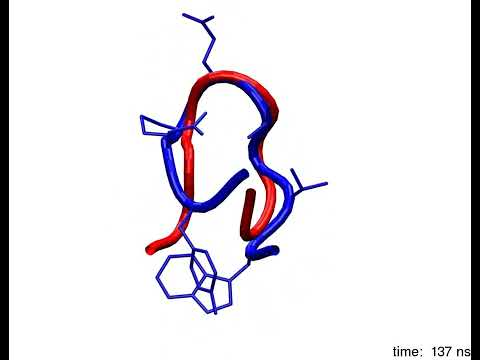

In [1]:
# Run this code cell to visualize the chignolin GAMD simulation
from IPython.display import YouTubeVideo
YouTubeVideo('mHiHxCe_3bc', width=800, height=450)

* **Q13** Does the GAMD movie display the real timescale for a protein folding event?    

### **GAMDs are biased simulations**

Clearly the boost potential is an artifact that cannot be associated with any physical effect. In this respect, GAMD simulations are *biased*  in order to  accelerate conformational transitions. However, it is necessary to *unbias*  the GAMD results to find out which of the conformation(s) visited during the simulation are really the most stable ones. This is a common problem when using  enhanced MD algorithms: the simulations must be post-processed to derive the unbiased probability density functions, a transformation that is known as **probability reweighing**. 

Probability reweighing is a non-trivial statistical problem. To begin with,  the dimensionality of the conformational phase space ($\sim 3N_{atoms}$)  must be drastically reduced to tackle this problem. In the context of GAMD simulations,  reweighing is performed in terms of one or two  *generalized coordinates* that are conveniently taken from  **global structural descriptors**.  In the APTAMD scripts, two  nearly-orthogonal descriptors are used:  
* the root-mean-squared-deviation (RMSD) of the heavy atoms (P,C,N,O) with respect to the initial structure.
* the interaction network fidelity  (INF) index, which measures the similarity between  a reference structure  and every  GAMD snapshot in terms of the number of base pairing/stacking contacts.

Details about  the RMSD and INF calculations will be provided in the next session because these descriptors are helpful to describe the evolution of any MD simulations. After the GAMD simulation is completed, the INF and RMSD values are calculated for every MD frame ($M\sim 10^5$ data pairs).    The 2D space defined by the $\left(\rm{INF},\rm{RMSD}\right)$ data is then divided into a grid of bins, setting a small number of bins along the RMSD and INF dimensions (e.g., $\sim  15-25$ bins) to minimize undersampling effects.  The  probability $P^\star$ of observing a molecular configuration  within a given bin   $\left(\rm{INF}_I,\rm{RMSD}_J\right)$ is directly estimated from the relative frequencies   (i.e. by counting the number of data points into each bin), resulting thus in a 2D histogram map of $P^\star$ values (see Fig 4).
      
[x]:![](PNG/rw.png)
<img src="./PNG/rw.png" width="720" height="480" style="display: block; margin: 0 auto">

**Fig 4**  Reweighing of GAMD simulations for aptamers. First, a 2D histogram of biased probabilities is built from the available $\left(\rm{INF},\rm{RMSD}\right)$ values. The $P^\star$  map is transformed into a 2D free energy map using statistical methods. Inspection of the free energy map reveals the most likely types of conformations.       

The $P^\star$ map derived from the GAMD simulation corresponds to a *biased* probability due to the presence of the boost potential. To transform $P^\star$ into the equilibrium (*unbiased*) $P$, it is necessary to reweigh each bin in the map using the statistical formula shown in **Fig 4**. Obtaining well-converged average values of the exponential form of the boost potential is very challenging, but in the case of GAMD, the adoption of the harmonic approximation, leads to $ \left\langle {\exp \left( {\frac{{ V_{boost}}}{{k_B T}}} \right)} \right\rangle  \simeq \exp \left\{ {\frac{{\left\langle { V_{boost}} \right\rangle }}{{k_B T}} + \frac{{\left\langle {{V_{boost}^2}} \right\rangle  - {{\left\langle { V_{boost}} \right\rangle }^2}}}{{2{{\left( {k_BT} \right)}^2}}}} \right\} $, in which more accessible   averages of $V_{boost}$ and $V_{boost}^2$ are used. Finally, the resulting $P$ values are transformed into **relative free energies** using the direct relationship $G=-RT\ln{P}$  .   

In the APTAMD protocol, the end result of the GAMD simulation is the **2D free energy  map $G\left(\rm{INF},\rm{RMSD}\right)$**. The $G$ map, which is actually a *pixelated image*,  must be carefully inspected to determine the most favorable regions of the PES. Care is needed here to exclude all bins that have low population (i.e. a low $P^\star$ value) because their energy reweighing is completely unreliable! Thus, **only the 2D basin(s) associated with significantly populated regions of the   $\left(\rm{INF},\rm{RMSD}\right)$ space must be considered to select one or more GAMD frames representing the most likely conformations of the aptamer molecule**. 

Clearly, the quality of a GAMD conformational search depends on a significant number of parameters, approximations and arbitrary choices.  Moreover, the length of the GAMD simulation is also a main factor determining the resolution and statistical confidence of the free energy map. 


## **Stages of an MD/GAMD simulation** 

The initial model system prepared by a molecular edition protocol (e.g. as that implemented by `do_aptamer_edition` ) is not *equilibrated*, meaning that the spatial distribution of water molecules, ions and probably groups of solute atoms does not reflect the desirable  thermodynamic conditions of constant $\left(NVT\right)$ or $\left(NPT\right)$ conditions. Moreover,  initial model usually contain structural defects ranging from steric clashes to misaligned non-covalent contacts that need to be corrected before recording any MD measurement. Therefore,  MD workflows contemplate several stages aimed to equilibrate the model system followed by a production phase. Each stage  employs different MD settings depending on its equilibration/production targets.    

Despite differences in technical details and methodological choices, such as the force field and thermostat, MD simulation workflows generally follow a similar sequence of operations. In this respect, the stages included in the **APTAMD protocol** including molecular edition, are representative of the procedures adopted in most MD protocols. 

The APTAMD simulation steps are organized by the `do_aptamer_edition` and `do_runmd` scripts, which drive all the required actions and preserve the intermediate files (inputs, outputs, coordinates, topology, trajectories, etc.) in separate directories for each stage: 
```
1.EDITION   2.RELAX_SOLVENT  3.THERMALIZATION  4.PRESSURIZATION   5.PRODUCTION
```

WARNING: **`cd` into the  simulation directory created in the previous session and double check that the MD simulation directories have been created and contain simulation output files**   

#### **1. Molecular edition**
* *Tasks*: Structural changes/ Solvent and counterion addition/ Parameter assignment / Creation of topology & coordinate files.   
#### **2. Solvent relaxation** 
In the initial solvent box, waters are placed at regular positions while ions are distributed randomly. Bulk density is not well described by the box. During this stage, waters and ions are relaxed by means of energy minimization and a short MD simulation.   
* *Tasks*: 2500 energy minimization steps relaxing  Waters/Ions (aptamer is fixed). Constant $\left(NPT\right)$ MD 100 ps $\Delta t=1$ fs moving only Waters/Ions. 2500 energy minimization steps (full system).

* **Q14** Is $t=100$ ps a reasonable  simulation length?

* **Q15** Examine the output files in `2.RELAX_SOLVENT` and find out whether or not the density of the box is relaxed.       

#### **3. Thermalization** 

MD workflows usually implement a gradual $T$  equilibration process: starting at  a low  value , $T$ is increased  through  a series of short MD runs at constant  $\left(NVT\right)$ conditions. This procedure ensures a gentle thermalization of potentially-important non-covalent contacts. 

* **Q16** Examine the output files in `3.THERMALIZATION`. Take note of the number, target $T$ and length of the  thermalization steps implemented in `do_runmd`  

* **Q17** Using Linux commands, extract the $T$ values along the equilibration runs. **What is the target $T$ ?** Is it  well equilibrated?    

#### **4. Pressurization** 
Prior to the production phase, the full system is pressurized during a constant  $\left(NPT\right)$ simulation.  

* **Q18** Examine the output files in `4.PRESSSURIZATION`. Take note of the **time step** and length of the simulation.   What type of motions can occur during the simulation? 

* **Q19** Using Linux commands, extract the density values along the pressurization run and calculate the corresponding mean and standard deviation.  

#### **5. GAMD or MD production phase**   

The last frame produced in the previous stage is taken as the origin (`frame  0`) of the constant $\left(NPT\right)$ production phase.  The settings of the production MD jobs are identical to those used in the pressurization stage.  

* **Warning** In the case of GAMD simulations, a preliminary MD run is required to derive the parameters for the boost potential. Input/output files for this preparatory run are named with the prefix `gamd_`. **These are not production files!**  

The production stage of an MD simulation is usually extended up to hundreds of ns and beyond. For the sake of data safety and efficiency considerations,   **it is always necessary to split the long run into a sequence of smaller  runs.** The filename convention adopted by the APTAMD scripts includes numerical labels to distinguish at a glance ordered lists of files .        
```
gamd_eq.mdcrd    ---> GaMD equilibration coordinates 
gamd_eq.out      ---> GaMD equilibiration output
gamd.log
gamd-restart.dat
gamd.rst
job_GAMD.sh
md_000.rst      ---> Starting point of the production phase = gamd.rst 
md_001.gamd_log ---> Log file with GaMD boost potential data
md_001.out      ---> PMEMD output files 
md_001.rst      ---> PMEMD restart file
md_001_solute.mdcrd     ---> Coordinates of the solute atoms along the simulation  
md_001_solutewat.mdcrd  ---> Coordinates of solute, counterions and a shell of waters 
md_002.gamd_log
md_002.out
md_002.rst
md_002_solute.mdcrd
md_002_solutewat.mdcrd
...
```
* **Q20** Examine now the files in the `5.PRODUCTION` directory and consider the following questions:
  1. How many jobs were run during the production phase? What is the total length of the simulation?
  2. Take note of the total wall time consumed by the production runs. 
  3. For a given MD segment, there may be several trajectory coordinate files (`.mdcrd`). Why? Should we keep all of them?
  4. If needed the MD simulation can be restarted from the last set of coordinates and velocities (`.rst` files). Open the `job_GAMD.sh` script and modify it to extend the simulation up to 750 ns (do not submit!).


## **Case study: Structural and energetic analysis of GaMD simulations**

### **Obtaining RSMD / INF data**
As previously discussed, the reweighing of GAMD simulations is performed assuming that each GAMD snapshot is uniquely  characterized by two structural indexes, the RMSD and INF values. In APTAMD, a single script `do_struct.sh`  processes all the GAMD trajectory files, evaluates the RMSD/INF values  using  the [`cpptraj`](https://amberhub.chpc.utah.edu/cpptraj/) and [DSSR](https://x3dna.org/) programs, calculates the statistical average and standard deviations of the RMSD/INF data and shows graphically their evolution along the GAMD trajectory.

To obtain the RMSD plot , the RGYR plot (*radius of gyration*, measuring the average distance of solute atoms to its center of mass), and the INF plots of the aptamer during a GAMD simulation, follow these guidelines:

* Move to your project directory, which in turn contains the simulation directory, `apt_GAMD`. 
```bash
cd  project
```
* Copy the input file for `do_struct.sh` provided in the APTAMD suite. Edit the input file and adapt it to your particular system name and other options (choose `NPROCS=8`).  
```bash
cp $APTAMD/EXAMPLE_INPUT_FILES/input_struct.src  apt_GAMD/
```
* The DSSR program, which is needed to calculate the DNA structural descriptors, demands much CPU time (expect about 1 h of wall time).  Submit then the job to the queue system:

```bash
qapta do_struct  apt_GAMD/input_struct.src`
```

*  The output files created by `do_struct` are  written in a new folder and subfolder `apt_GAMD/6.ANALYSIS/STRUCT`. The evolution of the RMSD/RGYR/INF descriptors is plotted along the GAMD trajectory. Visualize the `.png` files for RMSD and INF descriptors and assess the magnitude and relevance of the fluctuations. Are the RMSD and INF descriptors correlated?

### **Reweighing GAMD** 

Using the APTAMD scripts, the GAMD simulation is energetically reweighed in terms of the RMSD/INF coordinates to produce a 2D free energy map of the conformational space. The `do_reweight_gamd.sh` script  assembles all the necessary data files, selects a proper number of bins along the RMSD/INF coordinates and plots the free energy ($G$) and the logarithm of the unbiased population ($\log_{10}(P^\star)$) distribution over the 2D bins.  `do_reweight_gamd.sh` also selects a set of representative structures from the GAMD trajectory  and saves them in PDB format. 

The reweighing processing of the GAMD trajectory can be done in one step:

* Move to your project directory
```bash
cd  project
```
* Copy the example input file from the APTAMD suite:
```bash
cp $APTAMD/EXAMPLE_INPUT_FILES/input_rwgamd.src  apt_GAMD/
```
* Edit  `input_rwgamd.src` to modify the `MOL ` variable. Other options  should work well for most aptamers. 

* Submit the job to the queue system.  The reweighing process   normally takes a few minutes.  
```bash
qapta do_reweight_gamd  apt_GAMD/input_rwgamd.src
```

The output from `do_reweight_gamd` is saved into `6.ANALYSIS/RW_GAMD_ENE`. It may be interesting  to try different settings for reweighing (e.g., bin size) so that `do_reweight_gamd` creates specific subdirectories. Again many output files are produced, but  the `2D_RW.dat` file deserves particular attention because it identifies the most-likely GAMD structures using a syntax as:  
```
 Picking up snapshots bin= 10 for  E= 1.525000 POP= 0.030  X=  0.52  Y=  7.54 
   Snapshot 1   isnap= 33922   ID=33922  RC1= 0.522976 RC2= 7.681600 Boost= 2.736762
   bin= 10  isnap_in_crd= 13922  CRD_FILE= 2 
   ... 
````
In this example, snapshot # 33922 assigned to bin #10 (located on the free energy minimum) corresponds to snapshot #13922 in the GAMD trajectory segment #2. It has a low value of GAMD boost potential and could be selected for subsequent MD jobs. The coordinates are saved in a separate PDB file named as `snap_10_13922.pdb`. 

* Examine the reweighing output files in `6.ANALYSIS/RW_GAMD_ENE`. Visualize simultaneously  the `CE2.png` and `CE2_pop.png` files showing the 2D maps of the free energy and biased population. Take note of the location on the map of the free energy basins (ignore lowly populated areas!).

* Decoding the information in the `2D_RW.dat` may be tricky. Make sure that the lowest-energy snapshots selected by `do_reweight_gamd` correspond to the right basin region on the 2D map. Take note of their identity.
   1. **Use chimerax to superpose the selected GAMD models**
   2. **Which structure should we choose for the next step in the APTAMD protocol?**

###  **Launch a conventional MD simulation**

Conventional MD simulations (cMD) are absolutely needed to provide **equilibrium conformational sampling** of aptamer models. To start a cMD from a previously selected  GAMD structure, it is necessary to make a *new simulation directory* and repeat the preparatory steps:

* Create the simulation directory and the edition subdirectory (we employ now the `_MD` suffix!)
```bash
cd  project
mkdir apt_MD; cd apt_MD; mkdir 1.EDITION; cd 1.EDITION
```
* Copy the PDB file containing the initial structure that is now  one of the GAMD candidates. Assuming that `selected_file.pdb` is the selected GAMD structure (only solute atoms), a new edition step is then executed to build the topology files and the corresponding solvent box. Use the same edition settings that were considered for preparing the GAMD simulation:   

```bash
do_aptamer_edition  apt_initial.pdb
```

* Copy the example file for running cMD.  Edit the input file. Make sure that the  variable `TYPE`  is now declared as `TYPE=MD`.  

```bash
cd  project   
cp $APTAMD/EXAMPLE_INPUT_FILES/input_runmd.src  apt_MD/
gedit apt_MD/input_runmd.src
```

* Finally, submit the cMD job using your submission command:
```bash
qapta do_runmd  apt_MD/input_runmd.src   #  qapta was the command used in our local cluster!
```